# Summary
This notebook shows how SS-CASTLE, MS-CASTLE and MN-CASTLE can be used for causal structure learning from observational data.

Since MN-CASTLE exploits an estimate of the _Evolutionary Wavelet Spectrum_ (EWS), we will use the ```mvLSW``` R package to obtain it.
In order to use both R and Python, we resort to `rpy2` library.

# Library

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas_datareader as pdr
import pandas_datareader.data as web
import pyro
import rpy2.robjects as ro
import itertools
import seaborn as sns
import torch
import gpytorch

from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri, r
from distributions.Plackett_Luce import make_permutation_matrix
from models.deep_probabilistic.MNCASTLE import CausalOrder, CausalCoeff
from models.nonconv_opt.models import SSCASTLE, MSCASTLE
from pyro.infer import SVI, TraceGraph_ELBO
from pyro.optim import ClippedAdam
from tqdm.notebook import tqdm

# Convert pandas.DataFrames to R dataframes automatically.
pandas2ri.activate()

sns.set_context("talk")
plt.rcParams['text.usetex'] = True

c:\Users\Gabriele\anaconda3\envs\MCSLT2\lib\site-packages\rpy2\robjects\pandas2ri.py:17: FutureWarning: pandas.core.index is deprecated and will be removed in a future version.  The public classes are available in the top-level namespace.
  from pandas.core.index import Index as PandasIndex


In [2]:
#install/load the R package
package_name = "mvLSW"

try:
    mvLSW = importr(package_name)
except:
    ro.r(f'install.packages("{package_name}")')
    mvLSW = importr(package_name)
mvLSW

rpy2.robjects.packages.Package as a <module 'mvLSW'>

# Data

In this example we will download data from Fama French data library.

In [3]:
pdr.famafrench.get_available_datasets() #shows all available datasets from FF data library

['F-F_Research_Data_Factors',
 'F-F_Research_Data_Factors_weekly',
 'F-F_Research_Data_Factors_daily',
 'F-F_Research_Data_5_Factors_2x3',
 'F-F_Research_Data_5_Factors_2x3_daily',
 'Portfolios_Formed_on_ME',
 'Portfolios_Formed_on_ME_Wout_Div',
 'Portfolios_Formed_on_ME_Daily',
 'Portfolios_Formed_on_BE-ME',
 'Portfolios_Formed_on_BE-ME_Wout_Div',
 'Portfolios_Formed_on_BE-ME_Daily',
 'Portfolios_Formed_on_OP',
 'Portfolios_Formed_on_OP_Wout_Div',
 'Portfolios_Formed_on_OP_Daily',
 'Portfolios_Formed_on_INV',
 'Portfolios_Formed_on_INV_Wout_Div',
 'Portfolios_Formed_on_INV_Daily',
 '6_Portfolios_2x3',
 '6_Portfolios_2x3_Wout_Div',
 '6_Portfolios_2x3_weekly',
 '6_Portfolios_2x3_daily',
 '25_Portfolios_5x5',
 '25_Portfolios_5x5_Wout_Div',
 '25_Portfolios_5x5_Daily',
 '100_Portfolios_10x10',
 '100_Portfolios_10x10_Wout_Div',
 '100_Portfolios_10x10_Daily',
 '6_Portfolios_ME_OP_2x3',
 '6_Portfolios_ME_OP_2x3_Wout_Div',
 '6_Portfolios_ME_OP_2x3_daily',
 '25_Portfolios_ME_OP_5x5',
 '25_Portf

In [4]:
#Here we gather daily returns of 5 F-F equity risk factors for Europe.
#For details on factors construction see https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/f-f_5developed.html
#For a brief introduction to factor investing see https://en.wikipedia.org/wiki/Factor_investing
df = web.DataReader('Europe_5_Factors_Daily', 'famafrench')
print(df['DESCR'])
del df[0]['RF']
display(df)

Europe 5 Factors Daily
----------------------

This file was created using the 202206 Bloomberg database. Missing data are indicated by -99.99. 

  0 : (1287 rows x 6 cols)


{0:             Mkt-RF   SMB   HML   RMW   CMA
 Date                                      
 2017-07-26    1.03 -0.49 -0.13  0.24 -0.24
 2017-07-27   -0.38  0.12  0.03 -0.20 -0.60
 2017-07-28   -0.13  0.40  0.22 -0.35  0.05
 2017-07-31    0.49  0.38  0.14 -0.07  0.06
 2017-08-01    0.33 -0.35  0.01  0.32 -0.17
 ...            ...   ...   ...   ...   ...
 2022-06-24    2.64 -1.51 -1.00  0.68 -0.39
 2022-06-27    0.90  0.25 -0.33  0.01  0.04
 2022-06-28   -0.41 -0.06  0.99 -0.46  0.69
 2022-06-29   -1.23 -0.45 -0.24  0.64  0.13
 2022-06-30   -1.16  0.20 -1.03  0.35 -0.37
 
 [1287 rows x 5 columns],
 'DESCR': 'Europe 5 Factors Daily\n----------------------\n\nThis file was created using the 202206 Bloomberg database. Missing data are indicated by -99.99. \n\n  0 : (1287 rows x 6 cols)'}

In [5]:
#we restrict our analysis from 2020-01-01
df_final = df[0].loc["2020-01-01":][:512].copy()

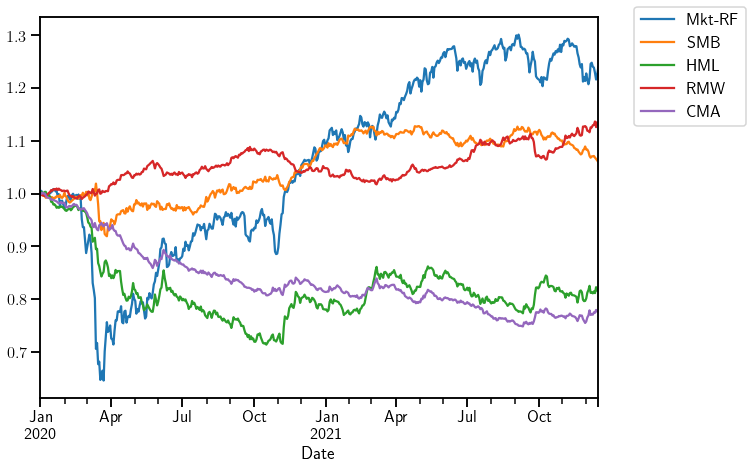

In [6]:
#here we visualize the behaviour of the factors strategies along time
np.cumprod(1+df_final/100).plot(figsize=(10,7))
plt.legend(bbox_to_anchor=(1.05,1.05))
plt.show()

In [14]:
#Now, we compute the EWS along with 90% CI throug mvLSW.

filternumber=5 #filter number of Daubechies wavelet

#EWS
EWS = mvLSW.mvEWS(df_final.values, filternumber) 
EWS_py=pandas2ri.ri2py(EWS[0])
N,_,J,T=EWS_py.shape

#Autocorrelation wavelet and variance of the estimate
ACW = mvLSW.AutoCorrIP(J, filternumber, "DaubExPhase")
VAR = mvLSW.varEWS(EWS, ACW)

#confidence intervals
CI = mvLSW.ApxCI(object=EWS, var=VAR, alpha=0.1)
CI_low=pandas2ri.ri2py(CI[0][0])
CI_up=pandas2ri.ri2py(CI[1][0])

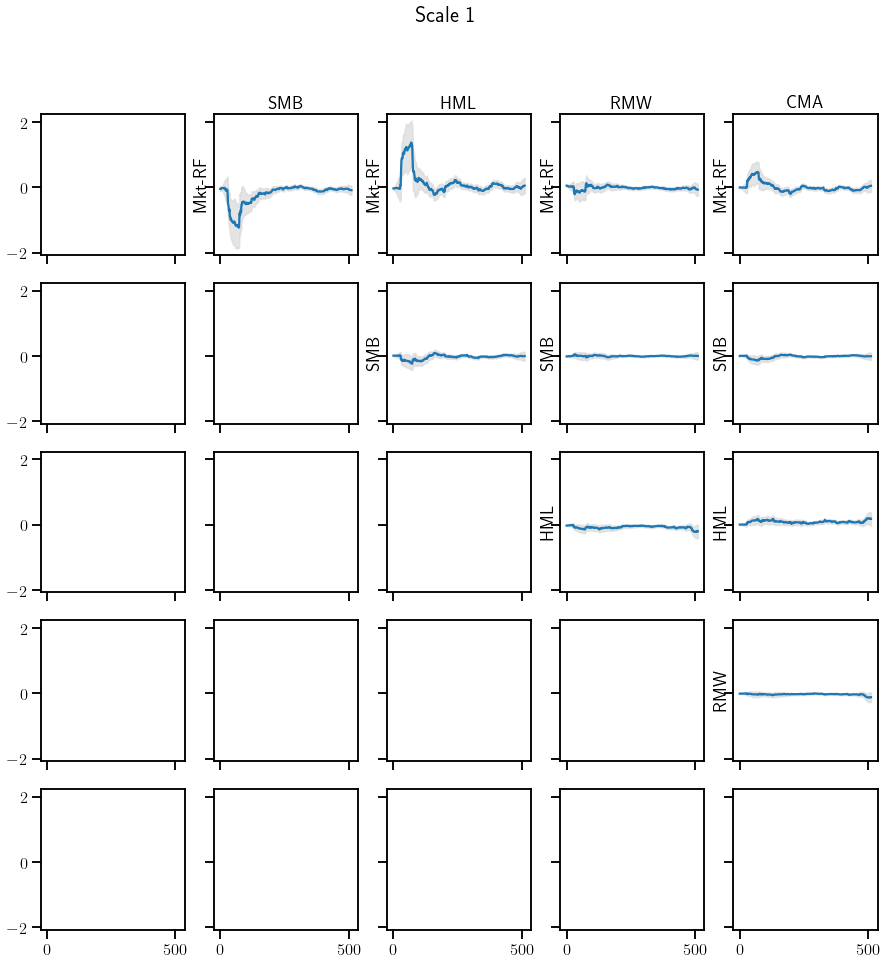

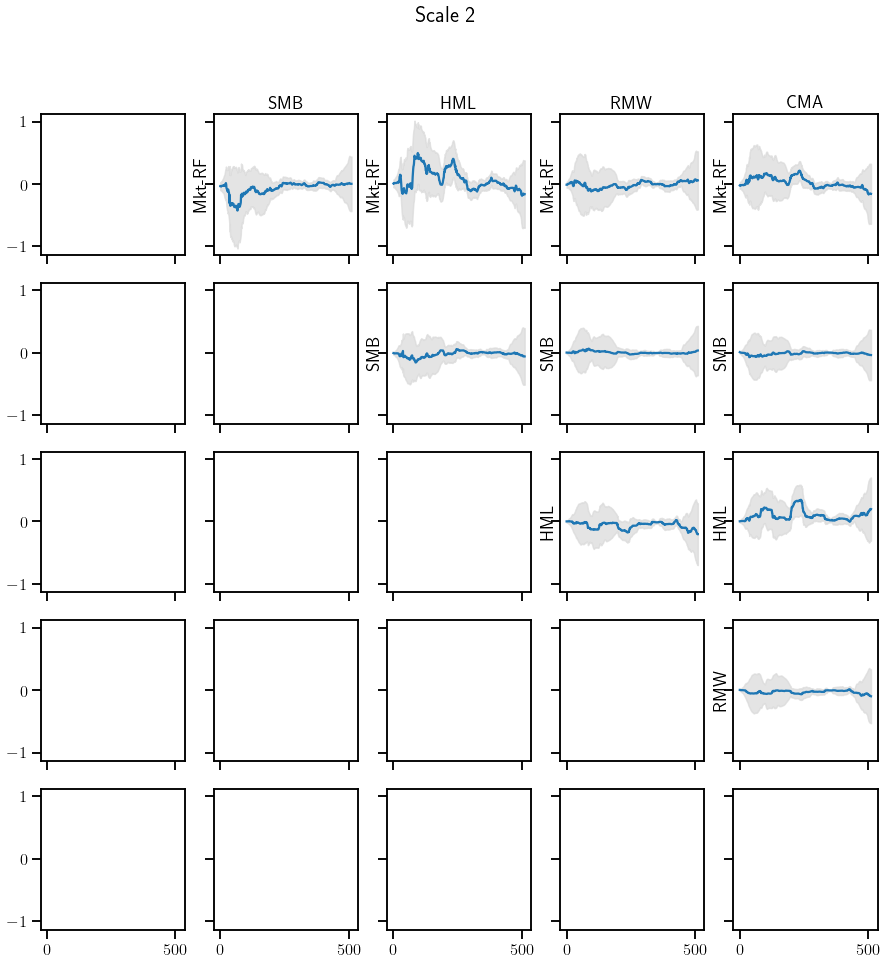

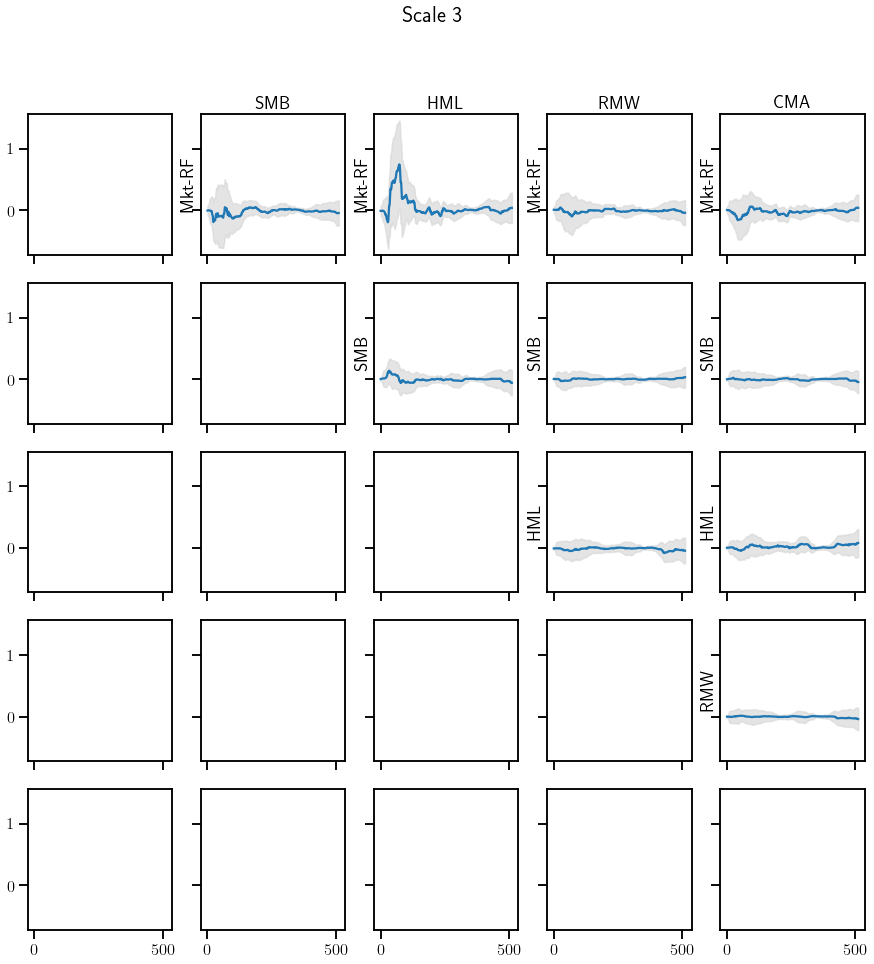

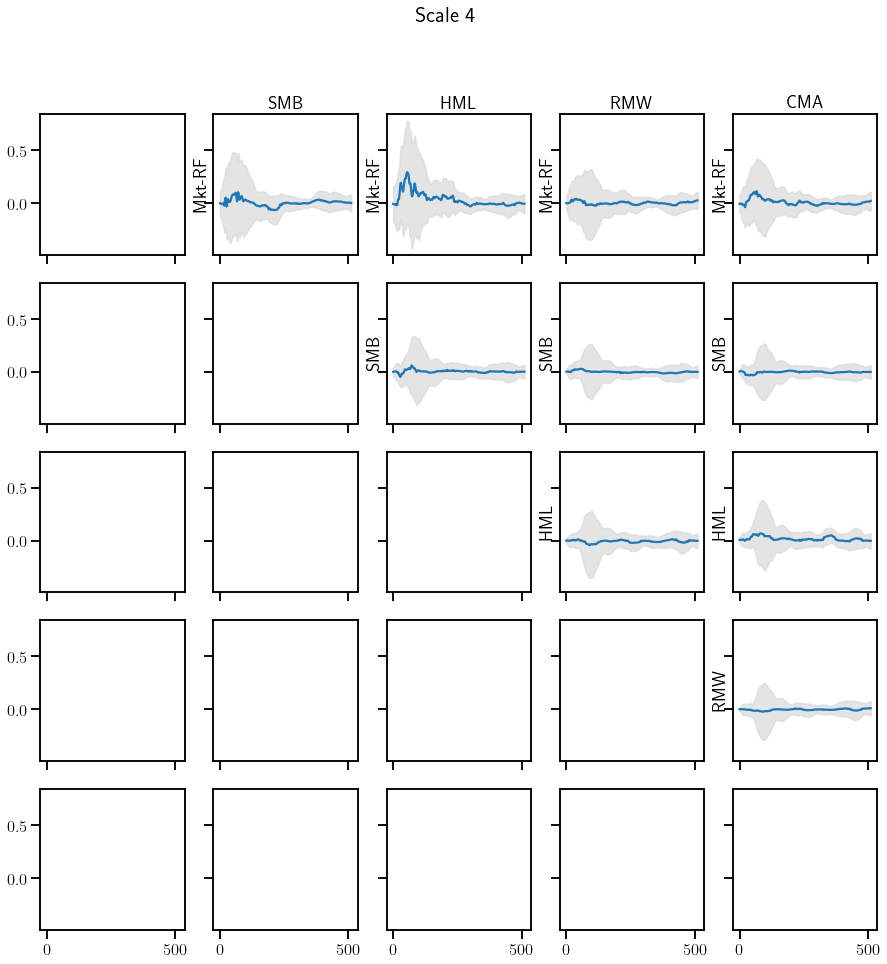

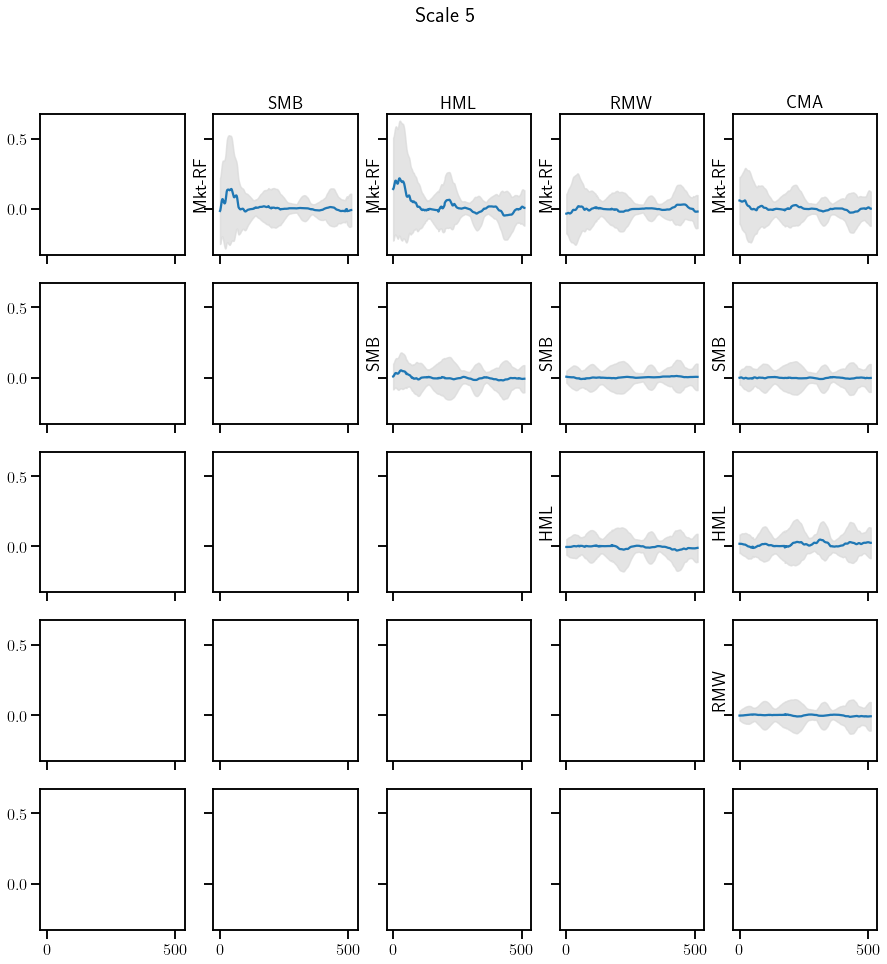

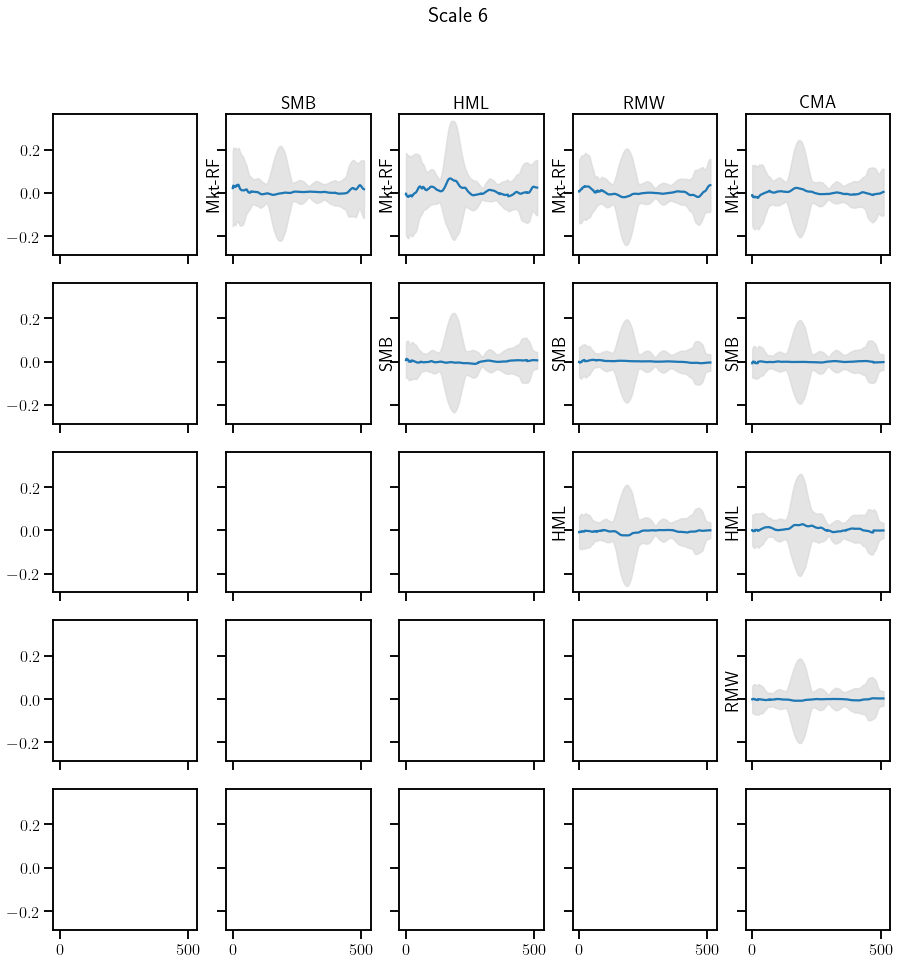

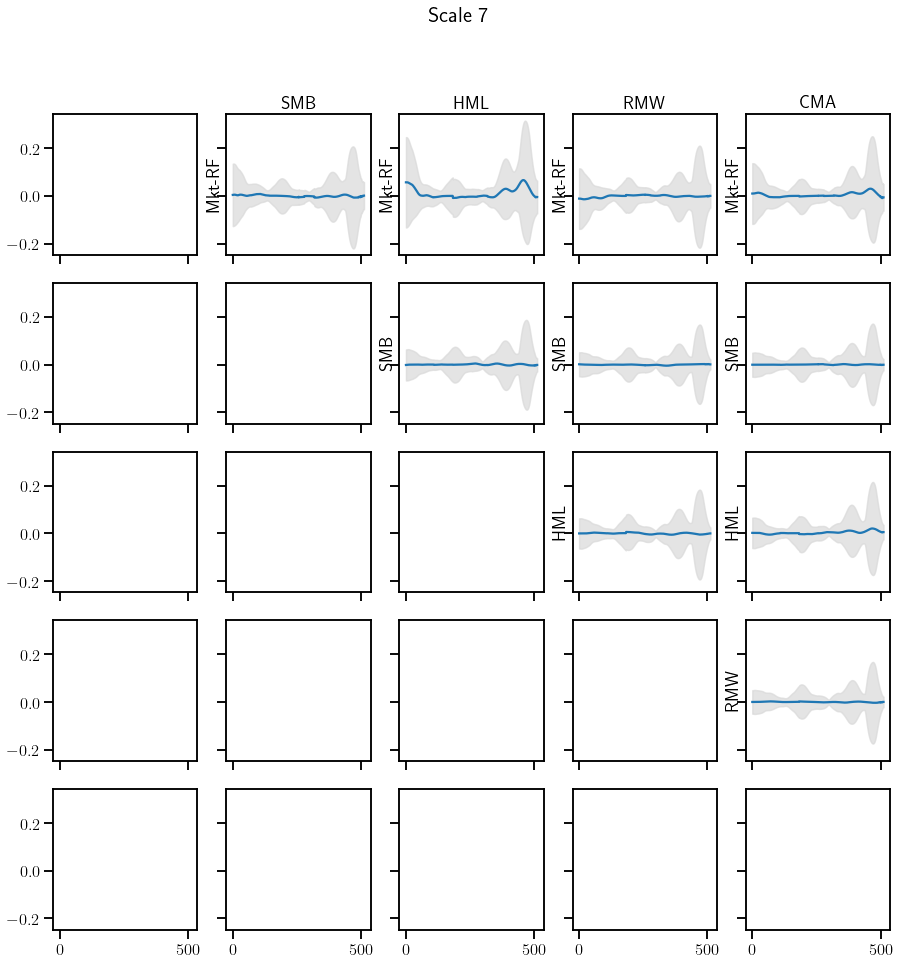

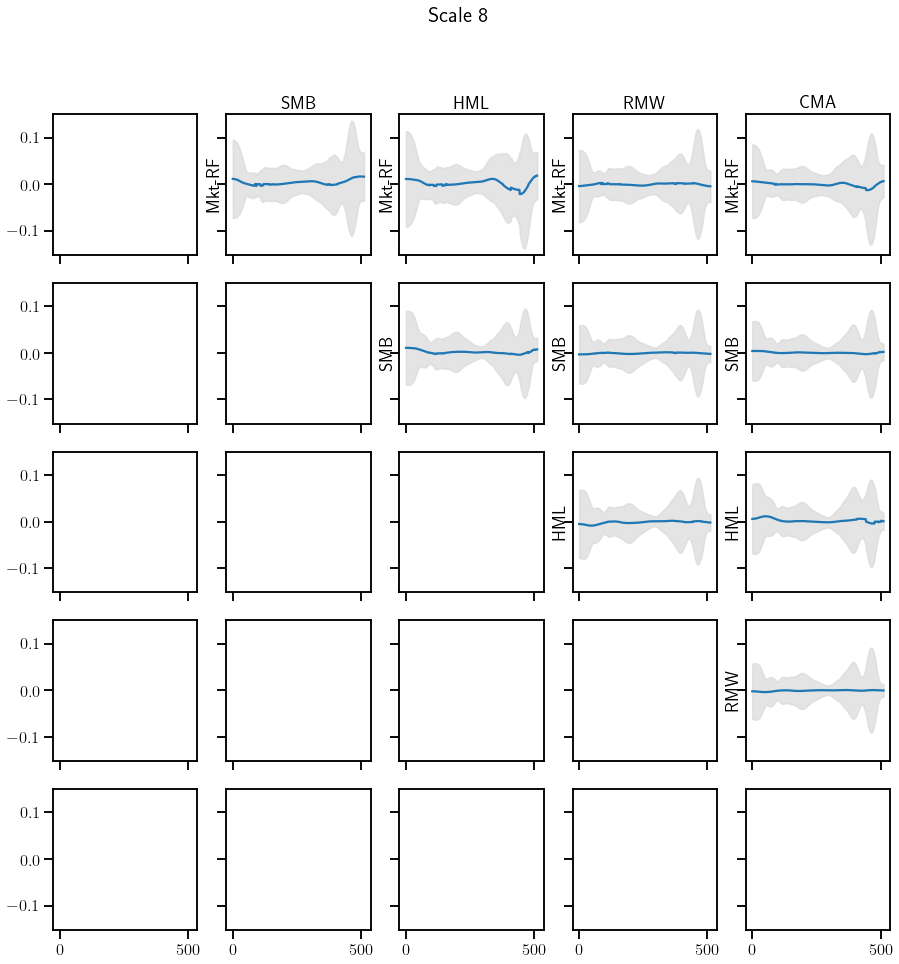

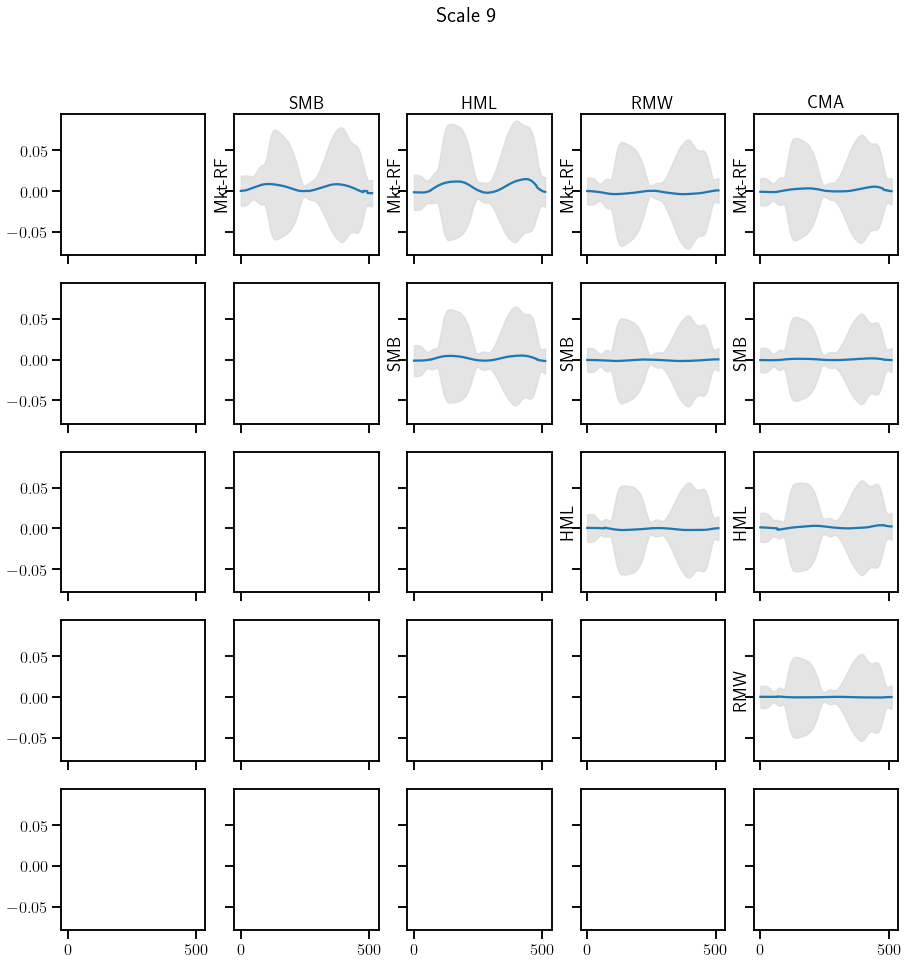

In [19]:
#Plot the estimates
#We notice that the most of the variance decomposes
#at first two scales.
T_tilde = T
N_tilde = N

for j in range(J):
    fig, ax= plt.subplots(N_tilde,N_tilde,sharex=True, sharey=True, figsize=(N_tilde*3,N_tilde*3))
    for n,m in itertools.combinations(range(N_tilde),2):
        if n==0:
            ax[n,m].set_title(df_final.columns[m]) 
        
        ax[n,m].set_ylabel(df_final.columns[n])   
        ax[n,m].plot(range(T_tilde), EWS_py[n,m,j, :T_tilde])
        ax[n,m].fill_between(
            range(T_tilde), CI_low[n,m,j,:T_tilde],
            CI_up[n,m,j, :T_tilde], color='#d9d9d9', alpha=0.7)
    plt.suptitle("Scale {}".format(j+1))
    plt.show()

# Inference
Here we apply the three models to retrieve the causal structure underlying data.
In particular, SS-CASTLE works on time domain whereas the MS-CASTLE and MN-CASTLE also exploit time-frequency analysis.

## SS-CASTLE

In [20]:
# Analisys in time domain
sscastle = SSCASTLE(df_final.values)
sscastle.lag

c:\Users\Gabriele\anaconda3\envs\MCSLT2\lib\site-packages\statsmodels\tsa\tsatools.py:824: FutureWarning: trend 'nc' has been renamed to 'n' after 0.14 is released. Use 'n' now to avoid this warning.
  FutureWarning,


0

In [21]:
#use l1 reg with lmbd=.05 and final hard-thresholding with threshold=.1
Cs, (it, t), loss, ell1 = sscastle.solver(reg='l1', lmbd=.05, thresh=.1, verbose=True)

Started iteration number  0
##### OPTIMIZATION INFO #####
Current value of objective function:  1.3483544245929437
Initial value of Frobenious norm:  1.2458501148983094
Initial value of reguralisation:  0.07085769157873532
|| W_bar-Z ||_F:  0.16227787298381172
Ended iteration number  0 . Dagness value equal to  0.0019871753539426606  (if DAG, h=0).
Started iteration number  1
##### OPTIMIZATION INFO #####
Current value of objective function:  1.2822246443411536
|| W_bar-Z ||_F:  0.02570447726052162
Ended iteration number  1 . Dagness value equal to  0.00473789153764681  (if DAG, h=0).
Started iteration number  2
##### OPTIMIZATION INFO #####
Current value of objective function:  1.1878865333982338
|| W_bar-Z ||_F:  0.022393535525126042
Ended iteration number  2 . Dagness value equal to  0.013930551545981551  (if DAG, h=0).
Started iteration number  3
##### OPTIMIZATION INFO #####
Current value of objective function:  1.1318886883286152
|| W_bar-Z ||_F:  0.01724027693419815
Ended iterat

In [22]:
CS_df = pd.DataFrame(data=Cs[0,...], columns=df_final.columns, index=df_final.columns)
CS_df

,Mkt-RF,SMB,HML,RMW,CMA
Mkt-RF,0.000000,0.0,0.000000,0.0,0.0
SMB,-0.810968,0.0,0.000000,0.0,0.0
HML,0.506013,0.0,0.000000,0.0,0.0
RMW,0.000000,0.0,-0.504348,0.0,0.0
CMA,-0.323953,0.0,0.872343,0.0,0.0


In the estimated causal matrix the parents are given on the rows.
SS-CASTLE suggests that causal interactions are only instantaneous and that:
- the market factor is causally impacted by SMB, HML and CMA;
- HML is causally impacted by RMW and CMA.

## MS-CASTLE

In [24]:
#Multiscale causal inference of stationary causal relations.
#Given the estimate of EWS, we focus only on the first two scales.
#We let the model to determine the number of lags.
mscastle = MSCASTLE(df_final.values, wavelet='db5', maxlags=40, ndetails=2)
mscastle.lag

c:\Users\Gabriele\anaconda3\envs\MCSLT2\lib\site-packages\statsmodels\tsa\tsatools.py:824: FutureWarning: trend 'nc' has been renamed to 'n' after 0.14 is released. Use 'n' now to avoid this warning.
  FutureWarning,


12

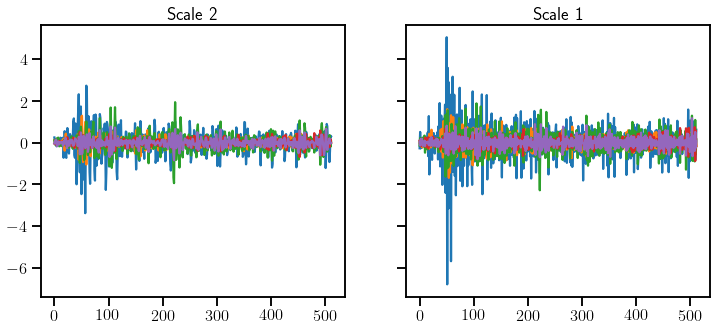

In [27]:
#Plot the computed detail coefficients

fig, ax = plt.subplots(1, mscastle.ndetails, sharex=True, sharey=True, figsize=(mscastle.ndetails*5+2, 5))
for nn in range(mscastle.ndetails):
    ax[nn].plot(range(T), mscastle.Y_dec[:,nn*5:(nn+1)*5])
    ax[nn].set_title("Scale {}".format(mscastle.ndetails-nn))
plt.show()

In [28]:
#use l1 reg with lmbd=.05 and final hard-thresholding with threshold=.1
Cs_ms, (it_ms, t_ms), loss_ms, ell1_ms = mscastle._solver(reg='l1', lmbd=.05, thresh=.1, verbose=True)


Started iteration number  0
##### OPTIMIZATION INFO #####
Current value of objective function:  0.8638462843078545
Initial value of Frobenious norm:  0.7520916115349505
Initial value of reguralisation:  0.2658495992038241
|| W_bar-Z ||_F:  0.32882380266442524
Ended iteration number  0 . Dagness value equal to  0.0002154646546976835  (if DAG, h=0).

Started iteration number  1
##### OPTIMIZATION INFO #####
Current value of objective function:  0.9344645639740696
|| W_bar-Z ||_F:  0.08704754171482036
Ended iteration number  1 . Dagness value equal to  0.000169931923043265  (if DAG, h=0).

Started iteration number  2
##### OPTIMIZATION INFO #####
Current value of objective function:  0.8799365084397474
|| W_bar-Z ||_F:  0.04601168020462767
Ended iteration number  2 . Dagness value equal to  0.0006334947555028947  (if DAG, h=0).

Started iteration number  3
##### OPTIMIZATION INFO #####
Current value of objective function:  0.8391712228901912
|| W_bar-Z ||_F:  0.029366144892333232
Ended i

In [85]:
import networkx as nx

lag: 0


,$Mkt-RF_{t}^{2}$,$SMB_{t}^{2}$,$HML_{t}^{2}$,$RMW_{t}^{2}$,$CMA_{t}^{2}$,$Mkt-RF_{t}^{1}$,$SMB_{t}^{1}$,$HML_{t}^{1}$,$RMW_{t}^{1}$,$CMA_{t}^{1}$
$Mkt-RF_{t}^{2}$,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
$SMB_{t}^{2}$,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
$HML_{t}^{2}$,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
$RMW_{t}^{2}$,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
$CMA_{t}^{2}$,0.0,0.0,0.105881,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
$Mkt-RF_{t}^{1}$,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
$SMB_{t}^{1}$,0.0,0.0,0.000000,0.0,0.0,-0.442855,0.0,0.000000,0.0,0.0
$HML_{t}^{1}$,0.0,0.0,0.000000,0.0,0.0,0.109908,0.0,0.000000,0.0,0.0
$RMW_{t}^{1}$,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,-0.162859,0.0,0.0
$CMA_{t}^{1}$,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.384308,0.0,0.0


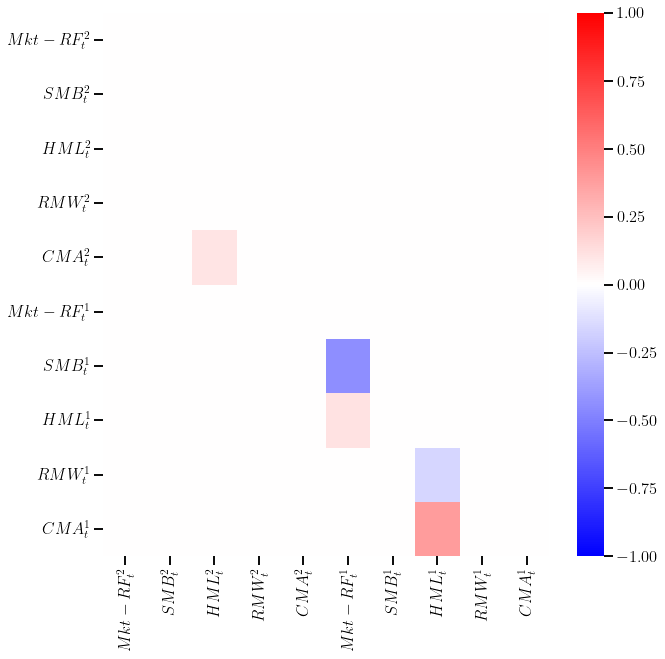

lag: 1


,$Mkt-RF_{t}^{2}$,$SMB_{t}^{2}$,$HML_{t}^{2}$,$RMW_{t}^{2}$,$CMA_{t}^{2}$,$Mkt-RF_{t}^{1}$,$SMB_{t}^{1}$,$HML_{t}^{1}$,$RMW_{t}^{1}$,$CMA_{t}^{1}$
$Mkt-RF_{t-1}^{2}$,0.289884,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
$SMB_{t-1}^{2}$,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
$HML_{t-1}^{2}$,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
$RMW_{t-1}^{2}$,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
$CMA_{t-1}^{2}$,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
$Mkt-RF_{t-1}^{1}$,0.000000,0.0,0.0,0.0,0.0,-0.489165,0.118476,0.000000,0.0,0.0
$SMB_{t-1}^{1}$,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
$HML_{t-1}^{1}$,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,-0.156841,0.0,0.0
$RMW_{t-1}^{1}$,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
$CMA_{t-1}^{1}$,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0


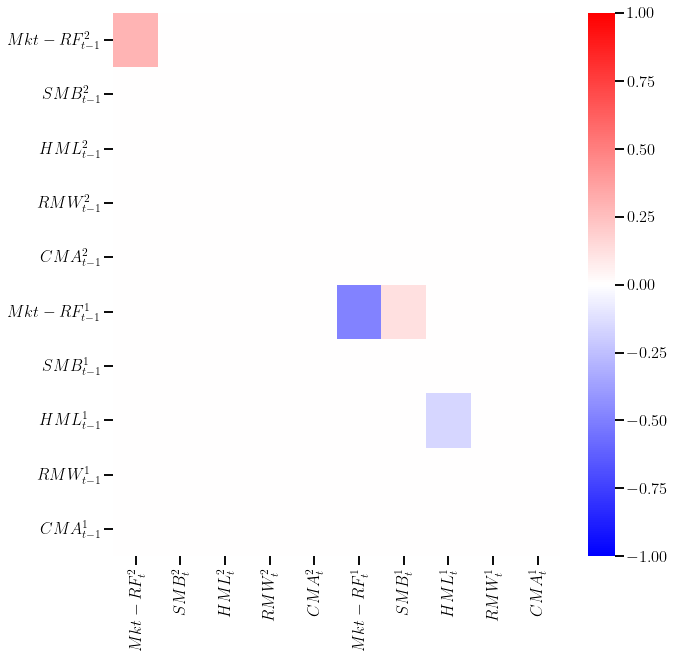

lag: 2


,$Mkt-RF_{t}^{2}$,$SMB_{t}^{2}$,$HML_{t}^{2}$,$RMW_{t}^{2}$,$CMA_{t}^{2}$,$Mkt-RF_{t}^{1}$,$SMB_{t}^{1}$,$HML_{t}^{1}$,$RMW_{t}^{1}$,$CMA_{t}^{1}$
$Mkt-RF_{t-2}^{2}$,-0.362211,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
$SMB_{t-2}^{2}$,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
$HML_{t-2}^{2}$,0.000000,0.0,-0.171145,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
$RMW_{t-2}^{2}$,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
$CMA_{t-2}^{2}$,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
$Mkt-RF_{t-2}^{1}$,0.000000,0.0,0.000000,0.0,0.0,-0.103291,0.0,0.0,0.0,0.0
$SMB_{t-2}^{1}$,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
$HML_{t-2}^{1}$,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
$RMW_{t-2}^{1}$,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
$CMA_{t-2}^{1}$,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


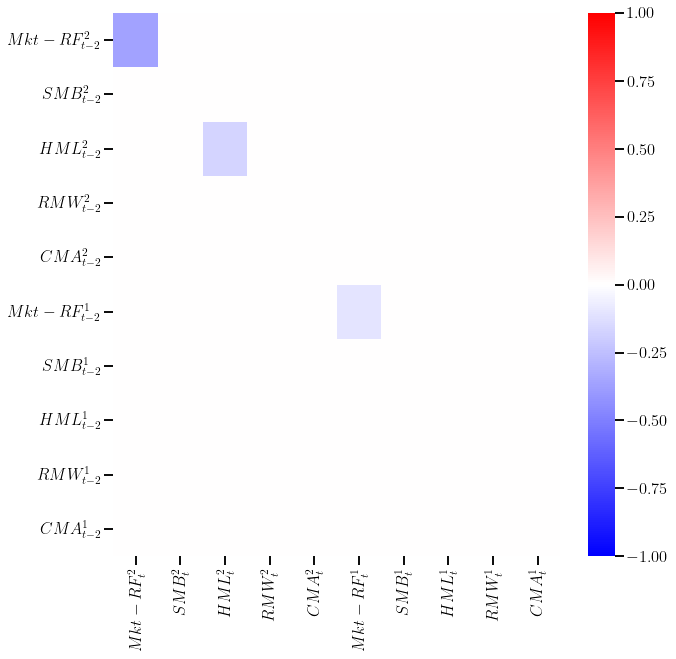

lag: 3
Relationships at lag 3 not found
lag: 4
Relationships at lag 4 not found
lag: 5
Relationships at lag 5 not found
lag: 6
Relationships at lag 6 not found
lag: 7
Relationships at lag 7 not found
lag: 8
Relationships at lag 8 not found
lag: 9
Relationships at lag 9 not found
lag: 10
Relationships at lag 10 not found
lag: 11
Relationships at lag 11 not found
lag: 12
Relationships at lag 12 not found


In [30]:
#Print the estimated weighted adjacencies for each lag.
#Subscripts represent the lag, superscripts the temporal resolution.
#Parents are given on the rows.
for l in range(Cs_ms.shape[0]):
    print('lag:', l)
    
    if len(np.flatnonzero(Cs_ms[l,...]))==0: print("Relationships at lag {} not found".format(l))
    else:
        cols=np.concatenate(["$"+df_final.columns+'_{t}^{%s}$'%(s) for s in range(mscastle.ndetails,0,-1)])
        if l==0: idxs=np.concatenate(["$"+df_final.columns+'_{t}^{%s}$'%(s) for s in range(mscastle.ndetails,0,-1)])
        else:  idxs=np.concatenate(["$"+df_final.columns+'_{t-%s}^{%s}$'%(l,s) for s in range(mscastle.ndetails,0,-1)])
        est = pd.DataFrame(data=Cs_ms[l,...], columns=cols, index=idxs)
        display(est)
        plt.figure(figsize=(10,10))
        sns.heatmap(est, vmin=-1, vmax=1, cmap='bwr')
        plt.show()

Looking at results, we see that:
- MS-CASTLE suggests that instantaneous causal interactions occur at both first and second scale. The signs are in accordance with those retrieved by SS-CASTLE.
- lagged interactions are mainly autoregressive and the maximum lag is 2. 
- MS-CASTLE provides more information than SS-CASTLE since it also finds instantaneous causal interactions at scale $j=2$ and lagged relationships.

## MN-CASTLE

In [31]:
#Multiscale non-stationary causal structure learning.
#Below we repeat the same steps as in notebook "example_deep_prob.ipynb"
S = torch.tensor(EWS_py, dtype=torch.float32).transpose(0,2).transpose(1,3)[:2] #look only at first 2 scales
X = torch.tensor(df_final.to_numpy(), dtype=torch.float32)

J, T, N, _ = S.size()

kernel =  gpytorch.kernels.RBFKernel(lengthscale_constraint=gpytorch.constraints.GreaterThan(1.),lengthscale_prior=None)
train_x = torch.linspace(0, 1, T, dtype=torch.float32).view(1,1,1,-1,1).repeat(J,N,N,1,1)

#adapted from https://github.com/cornellius-gp/gpytorch/blob/master/examples/07_Pyro_Integration/Cox_Process_Example.ipynb

def percentiles_from_samples(samples, percentiles=[0.01, 0.5, 0.99]):
    num_samples = samples.size(0)
    samples = samples.sort(dim=0)[0]

    # Get samples corresponding to percentile
    percentile_samples = [samples[int(num_samples * percentile)] for percentile in percentiles]

    return percentile_samples

In [32]:
pyro.clear_param_store()

num_iter=100
num_particles=10

def per_param_callable(param_name):
    global num_iter
    gamma = .1  # final learning rate will be gamma * initial_lr
    lrd = gamma ** (1 / num_iter)
    
    if 'baseline' in param_name:
        return {"lr":.03, 'betas':(.95,.999)}
    elif 'gp' in param_name:
        return {"lr":.05, 'lrd':lrd}
    else:
        return {"lr": .03, 'betas':(.95,.999), 'lrd':lrd}

def Alternating2step(train_x, X, S, kernel):
    
    J, T, N,_= S.size()
    model_order = CausalOrder(T,N)
    model_coeff = CausalCoeff(J,T,N,kernel=kernel, frac_inducing=.3)
    pyro.clear_param_store()
    optimizer = ClippedAdam(per_param_callable)
    elbo = TraceGraph_ELBO(num_particles=num_particles, vectorize_particles=False, retain_graph=True)
    svi_order = SVI(model_order.model, model_order.guide, optimizer, elbo)
    svi_coeff = SVI(model_coeff.model, model_coeff.guide, optimizer, elbo)

    model_coeff.train()
    iterator = tqdm(range(num_iter))
    for i in iterator:
        model_coeff.zero_grad()
        loss_order = svi_order.step(X)
        _b = pyro.param(model_order.name_prefix+'.theta').detach().data
        _, _order = _b.sort(descending=True)
        
        if i>25:
            loss_coeff = svi_coeff.step(train_x, _order, S)
            iterator.set_postfix(loss_order=loss_order,
                                 b=_b,
                                 loss_coeff=loss_coeff,
                                 nonstationarity=1./model_coeff.covar_module.base_kernel.lengthscale.detach().item())
        else:
            iterator.set_postfix(loss_order=loss_order,
                                 b=_b)
        
    test_x = torch.linspace(0, 1, T, dtype=torch.float32)
    
    model_coeff.eval()
    
    with torch.no_grad():
        output = model_coeff(test_x)    
        
    Nsamples = 1000
    samples=output(torch.Size([Nsamples]))
    lower, mean, upper = percentiles_from_samples(samples)
    ac_mean=mean.transpose(1,-1).transpose(-2,-1)
    ac_upper=upper.transpose(1,-1).transpose(-2,-1)
    ac_lower=lower.transpose(1,-1).transpose(-2,-1)
    
    theta_hat, co = pyro.param(model_order.name_prefix+".theta").cpu().detach().data.sort(descending=True)
    lengthscale = model_coeff.covar_module.base_kernel.lengthscale.cpu().detach().item()
    nonstationarity = 1./lengthscale
    c0 = model_coeff.mean_module.constant.cpu().detach().data.squeeze()
    return {
        'mean_GP': c0.numpy(),
        'ac_mean':ac_mean.numpy(),
        'ac_upper':ac_upper.numpy(),
        'ac_lower':ac_lower.numpy(),
        'b':theta_hat.numpy(),
        'causal ordering':co.numpy(),
        'lengthscale':lengthscale,
        'nonstationarity':nonstationarity}

In [33]:
%time results=Alternating2step(train_x, X, S, kernel) #otherwise uses Matern5/2 as default

  0%|          | 0/100 [00:00<?, ?it/s]

Wall time: 5min 53s


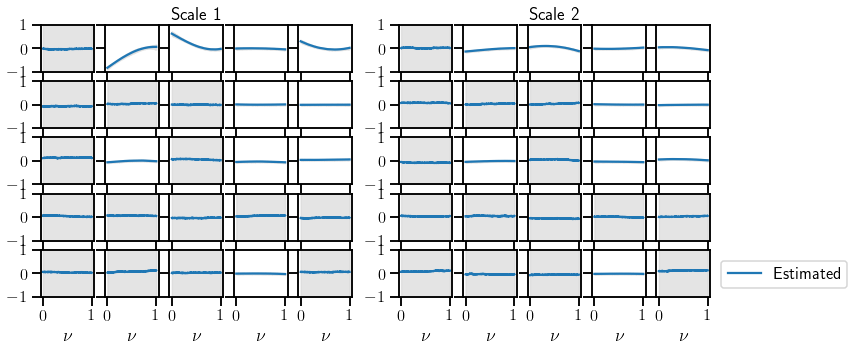

In [55]:
#parents are on the columns
test_x = torch.linspace(0, 1, T).float()

fig = plt.figure(figsize=(J*5+2,5))
outer_grid = fig.add_gridspec(1, int(J), wspace=0.15, hspace=0)

for scale in range(S.shape[0]):

    inner_grid = outer_grid[scale].subgridspec(N, N, wspace=0.2, hspace=0.2)
    title_ax = fig.add_subplot(inner_grid[:])
    title_ax.axis('off')
    title_ax.set_title('Scale {}'.format(scale+1))
    ax = inner_grid.subplots(sharey=True, sharex=True)
    
    for i,j in itertools.product(range(N), range(N)):
        ax[i,j].plot(test_x, results['ac_mean'][scale,:,i,j], label='Estimated')
        ax[i,j].fill_between(
            test_x, results['ac_lower'][scale,:,i,j],
            results['ac_upper'][scale,:,i,j], color='#d9d9d9', alpha=0.7
        )

        if i==N-1: ax[i,j].set_xlabel("$\\nu$")
        ax[i,j].set_ylim(-1,1)
ax[i,j].legend(bbox_to_anchor=[1.05, 0.], loc='lower left')

plt.show()

In [36]:
causal_adj = torch.zeros(results['mean_GP'].shape)
for j,n,m in itertools.product(range(causal_adj.shape[0]),range(causal_adj.shape[1]),range(causal_adj.shape[2])):
    
    hard_thresh=(np.minimum(np.abs(results['ac_lower'][j,:,n,m]),np.abs(results['ac_upper'][j,:,n,m]))>.1).sum()
    confidence=(np.sign(results['ac_lower'][j,:,n,m]*results['ac_upper'][j,:,n,m])).sum()

    #we register a causal connection if the causal coefficient is greater than .1 in abs value at 99% level
    #and lower and upper bounds have same sign.
    if hard_thresh>0 and confidence!=-results['ac_mean'].shape[1]: 
        causal_adj[j,n,m]+=1.

In [42]:
ordering_est = results['causal ordering']
B=torch.tril(torch.ones([N,N]), diagonal=-1)
P_=make_permutation_matrix(torch.tensor(ordering_est))
B=(P_.T@B@P_).expand(J,N,N)
causal_adj1 = B*causal_adj

print("Causal Ordering:")
df_final.columns[ordering_est].values

Causal Ordering:


array(['RMW', 'CMA', 'SMB', 'HML', 'Mkt-RF'], dtype=object)

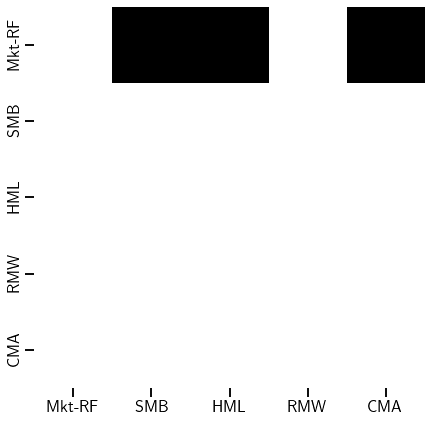

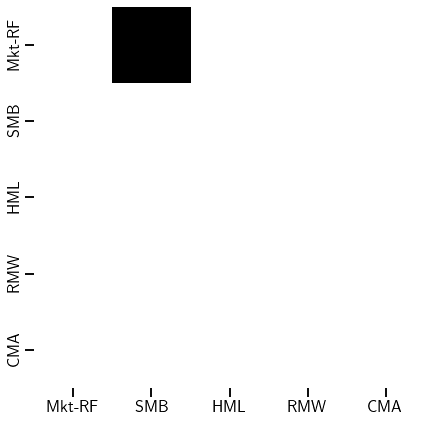

In [53]:
#here parents are on the columns
for j in range(J):
    plt.figure(figsize=(7,7))
    to_plot=pd.DataFrame(causal_adj1[j].numpy(), columns=df_final.columns, index=df_final.columns)
    sns.heatmap(to_plot, cmap='Greys',cbar=False)
    plt.show()

MN-CASTLE suggests same causal interactions as MS-CASTLE for market node. 

Moreover, it also provides the behaviour over time of such relations and an estimate of the causal ordering. In particular, from causal coefficients evolution we see that interactions are more intense at the beginning of the period (outbreak of covid-19 pandemic) and that SMB->Mkt interactions at second level is negligible.

Hence, MN-CASTLE tells us that causal links estimated by SS-CASTLE and MS-CASTLE are non-stationary and tend to vanish in the latter part of the considered period.